## LSTM

Long short term memory RNNs handle this using gates! Besides, unlike vanila RNNs, they have a long term memory component in addition to the short term memory ($h_{t-1} \rightarrow h_t$). To build an intuition, think of the long term memory as a conveyor belt (officially we call it Cell state). Information is put on the conveyor belt, at every step, the gates would determine what's to be forgotten (the forget gate), what incoming information is to be added to the conveyor belt (The input gate), and what part of the information on the conveyor belt is to be passed on to the output. 

To control this information flow, LSTMs use sigmoid and tanh functions. Sigmoids are used for gates (since they would constrain their outputs to between 0 and 1) while tanh output is always between -1 and 1 and can act as a valuing operation! 

### 1. Ingredients 
- $x_t$: The New Input (e.g., the current word you are reading).
- $h_{t-1}$: The Short-Term Memory (what happened just a moment ago - the same thing RNNs use).
- $C_{t-1}$: The Long-Term Memory (the "Cell State" that carries info across the whole sequence - the conveyor belt).

### 2. Forget gate
Determines what to toss out/discard. The first thing the LSTM does is look at the new input and the short-term memory to decide what part of the long-term memory is now irrelevant.

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

The Dot ($\cdot$): This is just a way of saying "multiply the inputs by their importance (weights).

"The Sigmoid ($\sigma$): It’s a function that squashes any number to a value between 0 and 1. If the result is 0, the gate "closes" (we forget this).If it’s 1, the gate "opens" (we keep this).

### 3. Input gate
What do we add to the conveyor belt. Now we decide what new information is worth saving for the long term. This happens in two parts.

- The Filter: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$(Decides which values we’ll update).
- The New Info: $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$(Creates a "candidate" vector of new information using tanh, which keeps values between -1 and 1).+1

### 4. Cell state: Updating the long term memory
Now we actually update the "conveyor belt" ($C_t$). We take the old memory, multiply it by the forget gate, and add the new information.

$$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$

- $f_t * C_{t-1}$: Old memory times the "forget" factor.
- $i_t * \tilde{C}_t$: New info times the "importance" factor.


### 5. Output gate
Finally, we need to decide what the "output" is for this specific moment. This becomes the new short-term memory ($h_t$).

- The Filter: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$(Decides which parts of the long-term memory we want to show right now).
- The Output: $h_t = o_t * \tanh(C_t)$(We take our long-term memory, squash it with $\tanh$, and multiply it by our filter).

Why we use sigmoids for gates and tanh for valuing?

- The Sigmoid: The "Gatekeeper"The Sigmoid function $(\sigma)$ squashes any input value to a range between 0 and 1.Why 0 to 1? Because in math, multiplying by 0 makes things disappear, and multiplying by 1 keeps them exactly as they are.

The Job: It acts as a binary-ish switch. When the LSTM calculates a gate (Forget, Input, or Output), it uses Sigmoid to ask: "How much of this should I let through?" * 0.05 = "Mostly block this."0.98 = "Let almost all of it through."2. 

- The Tanh: The "Regulator"The Tanh function squashes values to a range between -1 and 1.Why -1 to 1? This is about centered data. If we only used Sigmoids (0 to 1), every time we added new information to our Long-Term Memory (the Cell State), the values would only ever go up. Over thousands of steps, the numbers would explode to infinity, crashing the model.

The Job: Tanh allows the model to increase OR decrease the memory.A positive value adds to the memory.A negative value "subtracts" or pushes the memory in the opposite direction.Crucially, it keeps the numbers from getting too big or too small, keeping the "math" stable.

## The Full LSTM Equations

## LSTM Equations

At each time step $t$, the LSTM computes the following:

**Forget gate**
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

**Input gate**
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

**Candidate memory**
$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

**Cell State Update (Memory Highway)**
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

**Output Gate**
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

**Hidden State**
$$
h_t = o_t \odot \tanh(c_t)
$$

---

### Key Components

- $x_t$ : input at time $t$
- $h_t$ : hidden state
- $c_t$ : cell state (long-term memory)
- $\sigma(\cdot)$ : sigmoid activation
- $\odot$ : element-wise multiplication
- $W_*, U_*$ : learnable weight matrices
- $b_*$ : learnable biases




First we will build an LSTM from scratch. We can also use nn.LSTM. We will also compare the LSTM and vanila RNN from the previous section to see how LSTMs handle the vanishing gradients


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim

# ─── reproducibility ────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

In [2]:
def gradient_autopsy(T=50, hidden_size=32, input_size=1):
    """
    Forward pass of length T, then backprop.
    Returns gradient norms at each timestep.
    """
    rnn_cell = nn.RNNCell(input_size, hidden_size, nonlinearity='tanh')

    # Random input sequence — we don't care about the task here,
    # just the gradient flow.
    x = torch.randn(T, input_size)
    h = torch.zeros(hidden_size, requires_grad=False)

    # Store hidden states so we can call .retain_grad() on each
    hiddens = []
    for t in range(T):
        h = rnn_cell(x[t].unsqueeze(0), h.unsqueeze(0)).squeeze(0)
        h.retain_grad()          # ← normally intermediate grads are discarded
        hiddens.append(h)

    # Scalar loss at the very last timestep only
    loss = hiddens[-1].sum()
    loss.backward()

    # Collect ‖∂loss/∂h_t‖ for each t
    grad_norms = [h.grad.norm().item() for h in hiddens]
    return grad_norms

In [3]:
print("Running gradient autopsy …")
T = 60
grad_norms = gradient_autopsy(T=T)

# ─── also vary sequence length to show the trend ────────────────────────────
lengths = [10, 20, 40, 80]
grad_at_first_step = []
for length in lengths:
    norms = gradient_autopsy(T=length)
    grad_at_first_step.append(norms[0])   # gradient at t=0 (the oldest step)


Running gradient autopsy …


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# LONG-RANGE MEMORY TASK
# ════════════════════════════════════════════════════════════════════════════
#
# Task: "Echo the first token after a long silence"
#
# Input:  [signal, 0, 0, 0, …, 0]    (T tokens total)
# Target: predict the signal value at the LAST step
#
# The network must remember what it saw at t=0 across T-1 filler steps.
# Short sequences → easy. Long sequences → vanilla RNN forgets.
# ─────────────────────────────────────────────────────────────────────────────

In [28]:
"""
Vanishing Gradients in Vanilla RNNs
====================================

WHY THE PREVIOUS TASK KEPT FAILING TO SHOW THE PROBLEM:
  "Echo the first token" is always at position 0. The RNN exploits this:
  it learns to lock h_0 into a persistent pattern in Whh. It's not doing
  long-range memory, it's doing a fixed-position latch. Not a fair test.

THE FIX — The Adding Problem (Hochreiter & Schmidhuber, 1997):
  Input:  random floats in [0,1]  +  binary mask (two 1s at RANDOM positions)
  Target: sum of the two marked values
  Marked positions are random every batch → no fixed-position shortcut possible.
  Baseline MSE (always predict 1.0) ≈ 0.167

Requirements: pip install torch matplotlib numpy
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

RED  = "#e05c5c"
BLUE = "#4a90d9"
GRAY = "#888888"
BASELINE_MSE = 0.167   # Var of sum of two U(0,1) — model predicting mean gets this


# ════════════════════════════════════════════════════════════════════════════
# THE ADDING PROBLEM
# ════════════════════════════════════════════════════════════════════════════

def make_adding_batch(batch_size, seq_len):
    """
    Input shape:  (batch, seq_len, 2)
      channel 0 = random floats in [0, 1]
      channel 1 = binary mask — exactly two 1s at random positions

    Target: sum of channel-0 values at the two masked positions.

    Why the RNN fails: one marked position is often near t=0.
    The gradient back to that step passes through T-1 Whh multiplications
    and vanishes. The RNN cannot feel the early marker.
    The LSTM's cell state provides a near-direct gradient path past this.
    """
    values = torch.rand(batch_size, seq_len)
    mask   = torch.zeros(batch_size, seq_len)
    for i in range(batch_size):
        pos = torch.randperm(seq_len)[:2]
        mask[i, pos] = 1.0
    target = (values * mask).sum(dim=1)
    inputs = torch.stack([values, mask], dim=2)
    return inputs, target


# ════════════════════════════════════════════════════════════════════════════
# MODELS
# ════════════════════════════════════════════════════════════════════════════

class VanillaRNN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.rnn = nn.RNN(2, hidden, batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1]).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.lstm = nn.LSTM(2, hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze(-1)


def train(model, seq_len, epochs, batch_size=128, lr=1e-3):
    opt     = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []
    for _ in range(epochs):
        x, y = make_adding_batch(batch_size, seq_len)
        loss = loss_fn(model(x), y)
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
    return history


def smooth(x, w=50):
    if len(x) < w: return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')


# ════════════════════════════════════════════════════════════════════════════
# PART 1 — GRADIENT AUTOPSY  (mathematical fact, no training needed)
# ════════════════════════════════════════════════════════════════════════════

def gradient_autopsy(T, hidden=64):
    cell = nn.RNNCell(2, hidden, nonlinearity='tanh')
    x  = torch.randn(T, 2)
    h  = torch.zeros(hidden)
    hs = []
    for t in range(T):
        h = cell(x[t:t+1], h.unsqueeze(0)).squeeze(0)
        h.retain_grad()
        hs.append(h)
    hs[-1].sum().backward()
    return [h.grad.norm().item() for h in hs]

print("Part 1: Gradient autopsy …")
T_probe = 100
norms   = gradient_autopsy(T_probe)

T_range    = list(range(5, 105, 5))
g_at_start = []
underflow_T = None
for T in T_range:
    g = gradient_autopsy(T)[0]
    g_at_start.append(g)
    if g == 0.0 and underflow_T is None:
        underflow_T = T
        print(f"  !! Float32 underflow at T={T}: gradient is exactly 0.0")


# ════════════════════════════════════════════════════════════════════════════
# PART 2 — SHORT vs LONG  (T=10 vs T=100)
# ════════════════════════════════════════════════════════════════════════════

print("\nPart 2: Short T=10 …")
h_rnn_s  = train(VanillaRNN(), 10, 3000)
h_lstm_s = train(LSTMModel(),  10, 3000)

print("Part 2: Long T=100 …")
h_rnn_l  = train(VanillaRNN(), 100, 3000)
h_lstm_l = train(LSTMModel(),  100, 3000)

rnn_s_final  = float(np.mean(h_rnn_s[-100:]))
lstm_s_final = float(np.mean(h_lstm_s[-100:]))
rnn_l_final  = float(np.mean(h_rnn_l[-100:]))
lstm_l_final = float(np.mean(h_lstm_l[-100:]))


# ════════════════════════════════════════════════════════════════════════════
# PART 3 — EXPONENTIAL COST OF "JUST USE MORE EPOCHS"
# ════════════════════════════════════════════════════════════════════════════

print("\nPart 3: Epochs-needed vs T …")

probe_Ts   = [5, 10, 15, 20, 25, 30]
MAX_EPOCHS = 6000
TARGET     = BASELINE_MSE - 0.05   # need to beat baseline by meaningful margin

rnn_ep  = []
lstm_ep = []

for T in probe_Ts:
    print(f"  T={T} …", end=" ", flush=True)
    h_r = train(VanillaRNN(), T, MAX_EPOCHS)
    h_l = train(LSTMModel(),  T, MAX_EPOCHS)

    def first_beat(hist):
        s = smooth(hist, 40)
        idx = np.where(s < TARGET)[0]
        return int(idx[0]) + 40 if len(idx) else None

    ep_r = first_beat(h_r)
    ep_l = first_beat(h_l)
    rnn_ep.append(ep_r  if ep_r  else MAX_EPOCHS)
    lstm_ep.append(ep_l if ep_l else MAX_EPOCHS)
    print(f"RNN={'>' + str(MAX_EPOCHS) if not ep_r else ep_r}, "
          f"LSTM={'>' + str(MAX_EPOCHS) if not ep_l else ep_l}")

Part 1: Gradient autopsy …
  !! Float32 underflow at T=90: gradient is exactly 0.0

Part 2: Short T=10 …
Part 2: Long T=100 …

Part 3: Epochs-needed vs T …
  T=5 … RNN=120, LSTM=140
  T=10 … RNN=1082, LSTM=385
  T=15 … RNN=1421, LSTM=492
  T=20 … RNN=2038, LSTM=679
  T=25 … RNN=2862, LSTM=816
  T=30 … RNN=4303, LSTM=972



SUMMARY

Baseline MSE (predict mean 1.0 always): 0.1670

Gradient at t=0 for increasing T:
  T=  5: 8.49e-01
  T= 10: 5.15e-02
  T= 15: 3.37e-03
  T= 20: 1.59e-04
  T= 25: 1.35e-05
  T= 30: 2.02e-07
  T= 35: 1.10e-08
  T= 40: 6.89e-09
  T=90: EXACTLY 0.0  ← float32 underflow

Short T=10 (3000 ep): RNN=0.0133, LSTM=0.0002
Long  T=100 (3000 ep): RNN=0.1628, LSTM=0.0087

Epochs to beat baseline (T → epochs):
  T= 5: RNN=     120,  LSTM=140
  T=10: RNN=    1082,  LSTM=385
  T=15: RNN=    1421,  LSTM=492
  T=20: RNN=    2038,  LSTM=679
  T=25: RNN=    2862,  LSTM=816
  T=30: RNN=    4303,  LSTM=972

KEY LESSON:
  The old echo task let the RNN cheat with a fixed-position latch.
  The Adding Problem has random marked positions — no shortcut possible.

  At T=100, gradient at t=0 = exactly 0.0 in float32.
  No learning rate, no optimizer, no number of epochs can fix a zero gradient.
  More epochs only helps when the gradient is small-but-nonzero.
  Once it hits float zero, you're done.

  LST

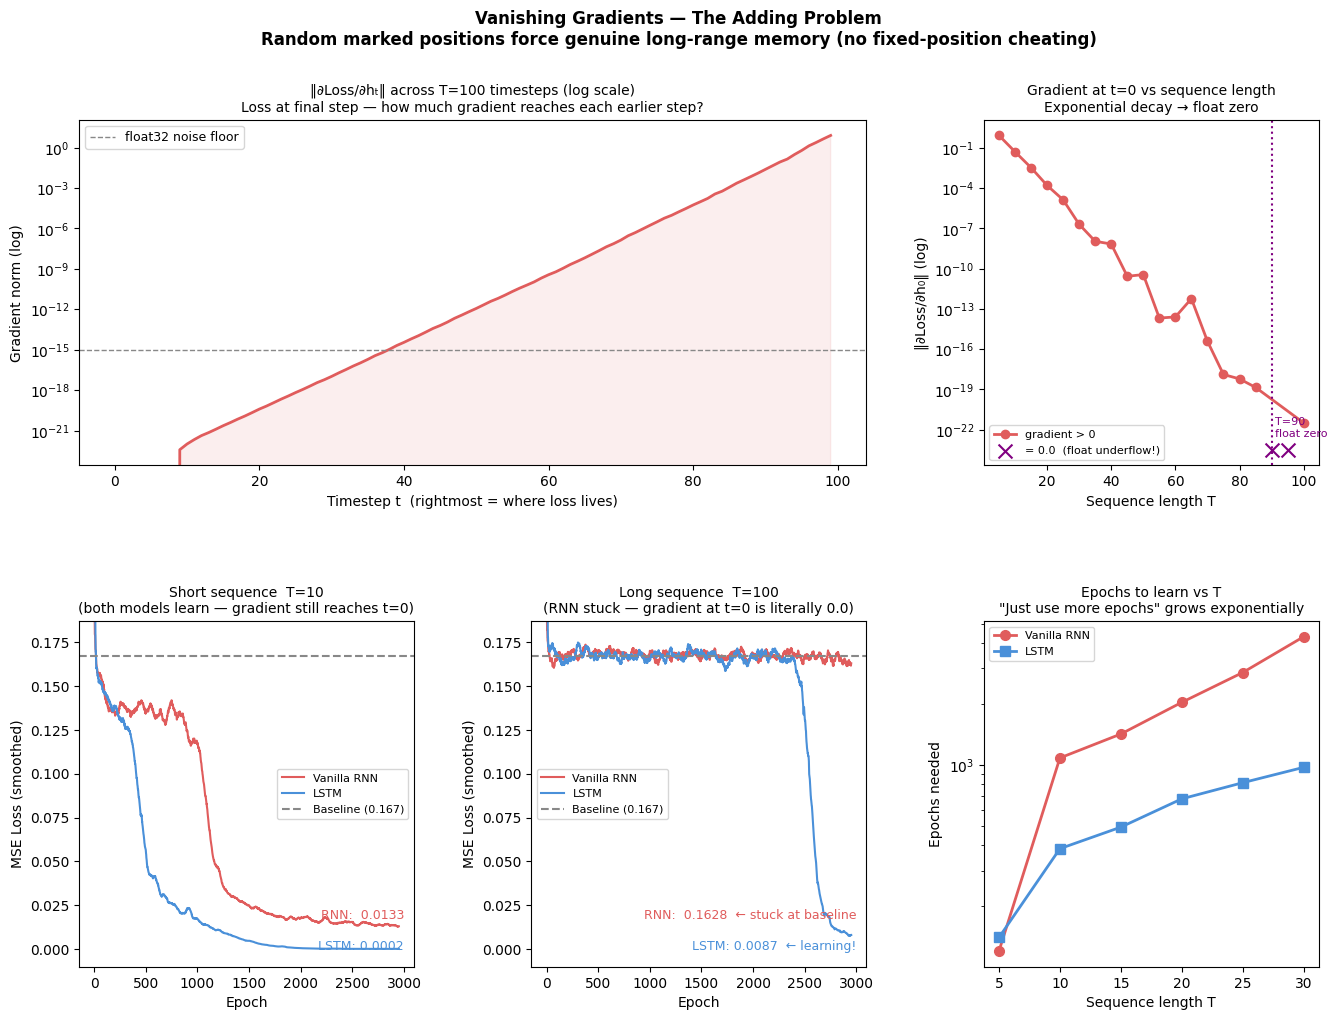

In [30]:
# ════════════════════════════════════════════════════════════════════════════
# PLOTTING
# ════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 11))
fig.suptitle(
    "Vanishing Gradients — The Adding Problem\n"
    "Random marked positions force genuine long-range memory (no fixed-position cheating)",
    fontsize=12, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: gradient along timesteps
ax1 = fig.add_subplot(gs[0, :2])
ax1.semilogy(range(T_probe), norms, color=RED, lw=2)
ax1.fill_between(range(T_probe), norms, alpha=0.1, color=RED)
ax1.axhline(1e-15, color=GRAY, ls='--', lw=1, label='float32 noise floor')
ax1.set_title(f"‖∂Loss/∂hₜ‖ across T={T_probe} timesteps (log scale)\n"
              "Loss at final step — how much gradient reaches each earlier step?", fontsize=10)
ax1.set_xlabel("Timestep t  (rightmost = where loss lives)")
ax1.set_ylabel("Gradient norm (log)")
ax1.legend(fontsize=9)

# Panel 2: gradient at t=0 vs T
ax2 = fig.add_subplot(gs[0, 2])
nz_T = [T for T, g in zip(T_range, g_at_start) if g > 0]
nz_g = [g for g in g_at_start if g > 0]
z_T  = [T for T, g in zip(T_range, g_at_start) if g == 0.0]

ax2.semilogy(nz_T, nz_g, 'o-', color=RED, lw=2, ms=6, label="gradient > 0")
if z_T:
    ax2.scatter(z_T, [min(nz_g)*0.01]*len(z_T), marker='x', color='purple',
                s=100, zorder=5, label="= 0.0  (float underflow!)")
if underflow_T:
    ax2.axvline(underflow_T, color='purple', ls=':', lw=1.5)
    ax2.text(underflow_T+1, min(nz_g)*0.1,
             f"T={underflow_T}\nfloat zero", fontsize=8, color='purple')
ax2.set_title("Gradient at t=0 vs sequence length\nExponential decay → float zero", fontsize=10)
ax2.set_xlabel("Sequence length T")
ax2.set_ylabel("‖∂Loss/∂h₀‖ (log)")
ax2.legend(fontsize=8)

# Panel 3: short sequence
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(smooth(h_rnn_s),  color=RED,  lw=1.5, label="Vanilla RNN")
ax3.plot(smooth(h_lstm_s), color=BLUE, lw=1.5, label="LSTM")
ax3.axhline(BASELINE_MSE, color=GRAY, ls='--', lw=1.5, label=f"Baseline ({BASELINE_MSE})")
ax3.set_title("Short sequence  T=10\n(both models learn — gradient still reaches t=0)", fontsize=10)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("MSE Loss (smoothed)")
ax3.set_ylim(-0.01, BASELINE_MSE + 0.02); ax3.legend(fontsize=8)
ax3.text(0.97, 0.14, f"RNN:  {rnn_s_final:.4f}", transform=ax3.transAxes,
         ha='right', fontsize=9, color=RED)
ax3.text(0.97, 0.05, f"LSTM: {lstm_s_final:.4f}", transform=ax3.transAxes,
         ha='right', fontsize=9, color=BLUE)

# Panel 4: long sequence
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(smooth(h_rnn_l),  color=RED,  lw=1.5, label="Vanilla RNN")
ax4.plot(smooth(h_lstm_l), color=BLUE, lw=1.5, label="LSTM")
ax4.axhline(BASELINE_MSE, color=GRAY, ls='--', lw=1.5, label=f"Baseline ({BASELINE_MSE})")
ax4.set_title("Long sequence  T=100\n(RNN stuck — gradient at t=0 is literally 0.0)", fontsize=10)
ax4.set_xlabel("Epoch"); ax4.set_ylabel("MSE Loss (smoothed)")
ax4.set_ylim(-0.01, BASELINE_MSE + 0.02); ax4.legend(fontsize=8)
rnn_tag  = "← stuck at baseline" if rnn_l_final  > 0.15 else "← learning!"
lstm_tag = "← learning!"         if lstm_l_final < 0.10 else "← also struggling"
ax4.text(0.97, 0.14, f"RNN:  {rnn_l_final:.4f}  {rnn_tag}",
         transform=ax4.transAxes, ha='right', fontsize=9, color=RED)
ax4.text(0.97, 0.05, f"LSTM: {lstm_l_final:.4f}  {lstm_tag}",
         transform=ax4.transAxes, ha='right', fontsize=9, color=BLUE)

# Panel 5: exponential cost
ax5 = fig.add_subplot(gs[1, 2])
rnn_s_T  = [T for T, ep in zip(probe_Ts, rnn_ep)  if ep < MAX_EPOCHS]
rnn_s_ep = [ep for ep in rnn_ep  if ep < MAX_EPOCHS]
rnn_x_T  = [T for T, ep in zip(probe_Ts, rnn_ep)  if ep >= MAX_EPOCHS]
lst_s_T  = [T for T, ep in zip(probe_Ts, lstm_ep) if ep < MAX_EPOCHS]
lst_s_ep = [ep for ep in lstm_ep if ep < MAX_EPOCHS]

ax5.plot(rnn_s_T,  rnn_s_ep,  'o-', color=RED,  lw=2, ms=7, label="Vanilla RNN")
ax5.plot(lst_s_T,  lst_s_ep,  's-', color=BLUE, lw=2, ms=7, label="LSTM")
for T in rnn_x_T:
    ax5.annotate("gave up →", xy=(T, MAX_EPOCHS), xytext=(T-5, MAX_EPOCHS*0.7),
                 fontsize=7, color=RED, arrowprops=dict(arrowstyle='->', color=RED))
ax5.set_title("Epochs to learn vs T\n\"Just use more epochs\" grows exponentially", fontsize=10)
ax5.set_xlabel("Sequence length T"); ax5.set_ylabel("Epochs needed")
ax5.set_yscale('log'); ax5.legend(fontsize=8)

# plt.savefig("/mnt/user-data/outputs/vanishing_gradients.png", dpi=150, bbox_inches='tight')
# print("\nSaved → vanishing_gradients.png")

# SUMMARY
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\nBaseline MSE (predict mean 1.0 always): {BASELINE_MSE:.4f}")
print(f"\nGradient at t=0 for increasing T:")
for T, g in zip(T_range[:8], g_at_start[:8]):
    print(f"  T={T:3d}: {g:.2e}")
if underflow_T:
    print(f"  T={underflow_T}: EXACTLY 0.0  ← float32 underflow")
print(f"\nShort T=10 (3000 ep): RNN={rnn_s_final:.4f}, LSTM={lstm_s_final:.4f}")
print(f"Long  T=100 (3000 ep): RNN={rnn_l_final:.4f}, LSTM={lstm_l_final:.4f}")
print(f"\nEpochs to beat baseline (T → epochs):")
for T, ep_r, ep_l in zip(probe_Ts, rnn_ep, lstm_ep):
    rs = str(ep_r) if ep_r < MAX_EPOCHS else f">{MAX_EPOCHS}"
    ls = str(ep_l) if ep_l < MAX_EPOCHS else f">{MAX_EPOCHS}"
    print(f"  T={T:2d}: RNN={rs:>8s},  LSTM={ls}")

print("""
KEY LESSON:
  The old echo task let the RNN cheat with a fixed-position latch.
  The Adding Problem has random marked positions — no shortcut possible.

  At T=100, gradient at t=0 = exactly 0.0 in float32.
  No learning rate, no optimizer, no number of epochs can fix a zero gradient.
  More epochs only helps when the gradient is small-but-nonzero.
  Once it hits float zero, you're done.

  LSTMs solve this not with magic — with a direct gradient path through
  the cell state that bypasses the repeated Whh multiplications entirely.
""")